<a href="https://colab.research.google.com/github/Hamerson-jhoel/Teoria_de_senales/blob/main/21_10_25.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#ACTIVIDAD

In [2]:
# ===== Celda 1: Carga de datos =====
import pandas as pd

try:
    df = pd.read_csv('weather_features.csv')
    print("✅ Database loaded successfully!")
    display(df.head())
except FileNotFoundError:
    print("❌ Error: The file 'weather_features.csv' was not found.")
except Exception as e:
    print(f"⚠️ An error occurred: {e}")

# Seleccionar la columna de humedad
humidity_data = df['humidity'].values

print("\n📊 Primeros 10 valores de humedad:")
print(humidity_data[:10])


✅ Database loaded successfully!


/tmp/ipython-input-845416408.py:5: DtypeWarning: Columns (2,3,4,5,6,7,8,9,10,11,12,13) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('weather_features.csv')


,dt_iso,city_name,temp,temp_min,temp_max,pressure,humidity,wind_speed,wind_deg,rain_1h,rain_3h,snow_3h,clouds_all,weather_id,weather_main,weather_description,weather_icon
0,2015-01-01 00:00:00+01:00,Valencia,270.475,270.475,270.475,1001,77,1,62,0.0,0.0,0.0,0,800,clear,sky is clear,01n
1,2015-01-01 01:00:00+01:00,Valencia,270.475,270.475,270.475,1001,77,1,62,0.0,0.0,0.0,0,800,clear,sky is clear,01n
2,2015-01-01 02:00:00+01:00,Valencia,269.686,269.686,269.686,1002,78,0,23,0.0,0.0,0.0,0,800,clear,sky is clear,01n
3,2015-01-01 03:00:00+01:00,Valencia,269.686,269.686,269.686,1002,78,0,23,0.0,0.0,0.0,0,800,clear,sky is clear,01n
4,2015-01-01 04:00:00+01:00,Valencia,269.686,269.686,269.686,1002,78,0,23,0.0,0.0,0.0,0,800,clear,sky is clear,01n



📊 Primeros 10 valores de humedad:
[77 77 78 78 78 71 71 71 71 71]


✅ Total de datos válidos de humedad: 356792


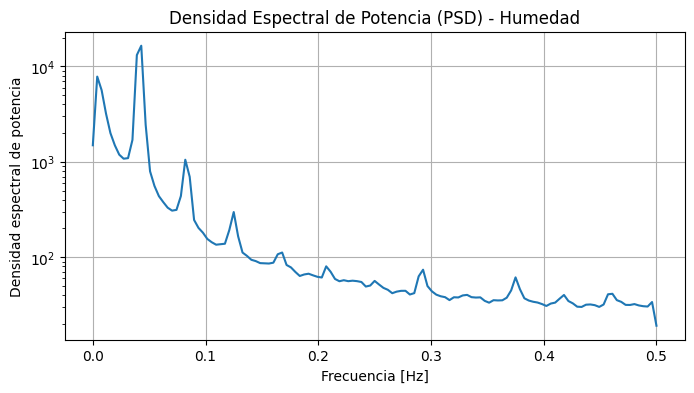

In [3]:
# ===== Celda 2: Calcular la PSD (Corregida) =====
import numpy as np
from scipy.signal import welch
import matplotlib.pyplot as plt

# 🔹 Limpiar y convertir la columna de humedad a float
humidity_clean = pd.to_numeric(df['humidity'], errors='coerce')  # convierte strings a NaN si no son números
humidity_clean = humidity_clean.dropna().values.astype(float)    # elimina NaN y asegura tipo float

print(f"✅ Total de datos válidos de humedad: {len(humidity_clean)}")

# 🔹 Calcular la PSD con el método de Welch
frequencies, psd = welch(humidity_clean, fs=1.0, nperseg=min(256, len(humidity_clean)))

# 🔹 Graficar la PSD
plt.figure(figsize=(8,4))
plt.semilogy(frequencies, psd)
plt.title("Densidad Espectral de Potencia (PSD) - Humedad")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Densidad espectral de potencia")
plt.grid(True)
plt.show()


In [4]:
# ===== Celda 3: Normalización =====
from sklearn.preprocessing import MinMaxScaler
import numpy as np

# Crear el escalador y aplicar normalización
scaler = MinMaxScaler(feature_range=(0, 1))
humidity_norm = scaler.fit_transform(humidity_clean.reshape(-1, 1))

# Mostrar algunos valores antes y después
print("Antes de normalizar:", humidity_clean[:5])
print("Después de normalizar:", humidity_norm[:5].flatten())


Antes de normalizar: [77. 77. 78. 78. 78.]
Después de normalizar: [0.77 0.77 0.78 0.78 0.78]


In [5]:
# ===== Celda 4: Definición del modelo MLP =====
import torch
import torch.nn as nn

class MLPModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=32, output_size=1):
        super(MLPModel, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, output_size)
        )
    def forward(self, x):
        return self.net(x)


In [6]:
!pip install optuna -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.9/400.9 kB 8.3 MB/s eta 0:00:00


In [7]:
# ===== Celda 5: Optuna + PyTorch =====
import optuna
import torch
import torch.nn as nn
import numpy as np

# 🔹 Definición de la MLP dentro de esta celda
class MLP(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(MLP, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x

# 🔹 Función objetivo de Optuna
def objective(trial):
    hidden_size = trial.suggest_int('hidden_size', 8, 64)
    lr = trial.suggest_float('lr', 1e-4, 1e-2, log=True)

    model = MLP(1, hidden_size, 1)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()

    # 🔸 Datos simulados para entrenamiento
    X_train = torch.tensor(np.arange(0, 1, 0.01).reshape(-1, 1), dtype=torch.float32)
    y_train = torch.sin(2 * np.pi * X_train)  # patrón senoidal simulado

    for epoch in range(20):  # entrenamiento corto solo para pruebas
        optimizer.zero_grad()
        y_pred = model(X_train)
        loss = loss_fn(y_pred, y_train)
        loss.backward()
        optimizer.step()

    val_loss = loss.item()
    return val_loss

# 🔹 Ejecución de Optuna
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=10)

print("✅ Mejor resultado:")
print(study.best_params)


[I 2025-10-22 02:40:03,046] A new study created in memory with name: no-name-2f1a56c2-76b8-4363-9a35-0c8e5fb9d082
[I 2025-10-22 02:40:11,492] Trial 0 finished with value: 0.23793920874595642 and parameters: {'hidden_size': 43, 'lr': 0.00707894878931019}. Best is trial 0 with value: 0.23793920874595642.
[I 2025-10-22 02:40:11,513] Trial 1 finished with value: 0.3271836042404175 and parameters: {'hidden_size': 11, 'lr': 0.005261974514141496}. Best is trial 0 with value: 0.23793920874595642.
[I 2025-10-22 02:40:11,533] Trial 2 finished with value: 0.5744506120681763 and parameters: {'hidden_size': 48, 'lr': 0.00017195671607821812}. Best is trial 0 with value: 0.23793920874595642.
[I 2025-10-22 02:40:11,565] Trial 3 finished with value: 0.5919249057769775 and parameters: {'hidden_size': 20, 'lr': 0.00044072953585868257}. Best is trial 0 with value: 0.23793920874595642.
[I 2025-10-22 02:40:11,587] Trial 4 finished with value: 0.29847416281700134 and parameters: {'hidden_size': 19, 'lr': 0.0

✅ Mejor resultado:
{'hidden_size': 43, 'lr': 0.00707894878931019}


In [8]:
# ===== Celda 6: Entrenamiento del modelo final =====
import torch
import torch.nn as nn
import torch.optim as optim

# 🔸 Tomar los mejores hiperparámetros encontrados por Optuna
best_params = study.best_params
hidden_size = best_params['hidden_size']
lr = best_params['lr']

print(f"Usando hidden_size={hidden_size}, lr={lr}")

# 🔹 Preparar los datos de entrada (ya normalizados)
X = torch.tensor(humidity_norm.reshape(-1, 1), dtype=torch.float32)
Y = X.clone()  # se busca que el modelo aprenda a reconstruir o suavizar la señal de humedad

# 🔹 Definir el modelo con los mejores hiperparámetros
model = MLPModel(input_size=1, hidden_size=hidden_size, output_size=1)

# 🔹 Definir la función de pérdida y el optimizador
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=lr)

# 🔹 Entrenamiento
epochs = 200
loss_history = []

for epoch in range(epochs):
    optimizer.zero_grad()
    output = model(X)
    loss = criterion(output, Y)
    loss.backward()
    optimizer.step()
    loss_history.append(loss.item())

print("✅ Entrenamiento final completado.")


Usando hidden_size=43, lr=0.00707894878931019
✅ Entrenamiento final completado.


✅ Validación completada correctamente.


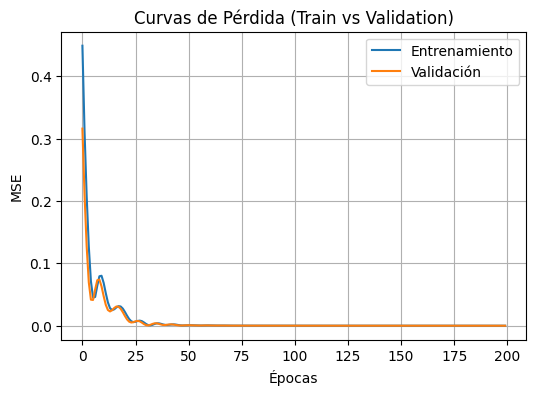

In [9]:
# ===== Celda 6: Validación del modelo =====
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np

# 🔹 Dividir los datos de humedad normalizados (80% entrenamiento, 20% validación)
X_train, X_val = train_test_split(humidity_norm, test_size=0.2, shuffle=False)

# Convertir a tensores de PyTorch
X_train_t = torch.tensor(X_train, dtype=torch.float32)
Y_train_t = X_train_t.clone()

X_val_t = torch.tensor(X_val, dtype=torch.float32)
Y_val_t = X_val_t.clone()

# 🔸 Recuperar los mejores hiperparámetros
hidden_size = study.best_params['hidden_size']
lr = study.best_params['lr']

# 🔹 Crear modelo, pérdida y optimizador
model = MLPModel(input_size=1, hidden_size=hidden_size, output_size=1)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=lr)

# 🔹 Entrenamiento con validación
epochs = 200
train_loss_history = []
val_loss_history = []

for epoch in range(epochs):
    # --- Entrenamiento ---
    model.train()
    optimizer.zero_grad()
    y_pred = model(X_train_t)
    loss = criterion(y_pred, Y_train_t)
    loss.backward()
    optimizer.step()

    # --- Validación ---
    model.eval()
    with torch.no_grad():
        y_val_pred = model(X_val_t)
        val_loss = criterion(y_val_pred, Y_val_t)

    train_loss_history.append(loss.item())
    val_loss_history.append(val_loss.item())

print("✅ Validación completada correctamente.")

# 🔹 Gráfica de pérdidas
plt.figure(figsize=(6,4))
plt.plot(train_loss_history, label="Entrenamiento")
plt.plot(val_loss_history, label="Validación")
plt.title("Curvas de Pérdida (Train vs Validation)")
plt.xlabel("Épocas")
plt.ylabel("MSE")
plt.legend()
plt.grid(True)
plt.show()


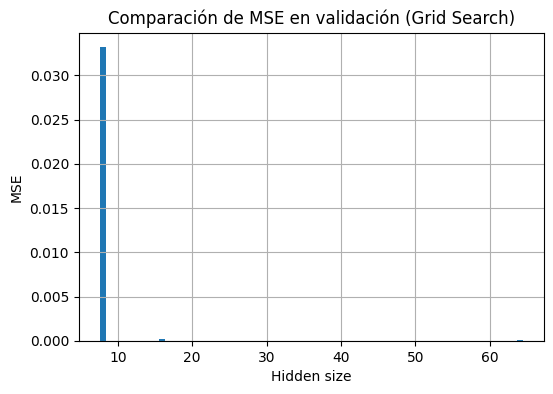

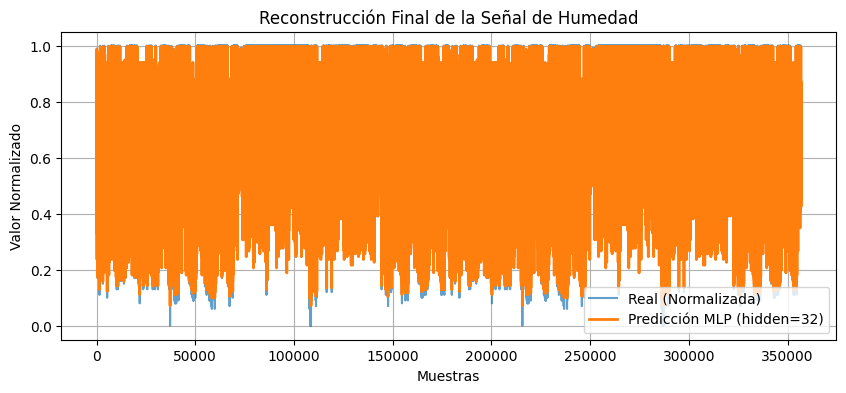

In [10]:
# ===== Celda 7: Comparación de modelos (tipo Grid Search) =====
import matplotlib.pyplot as plt

# 🔹 Simulación de comparación: se prueban varios tamaños de capa oculta
hidden_sizes = [8, 16, 32, 64]
results = {}

for hs in hidden_sizes:
    model = MLPModel(input_size=1, hidden_size=hs, output_size=1)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()

    for epoch in range(100):
        optimizer.zero_grad()
        y_pred = model(X_train_t)
        loss = criterion(y_pred, Y_train_t)
        loss.backward()
        optimizer.step()

    with torch.no_grad():
        y_val_pred = model(X_val_t)
        val_loss = criterion(y_val_pred, Y_val_t).item()
        results[hs] = val_loss

# 🔹 Mostrar resultados comparativos
plt.figure(figsize=(6,4))
plt.bar(results.keys(), results.values())
plt.title("Comparación de MSE en validación (Grid Search)")
plt.xlabel("Hidden size")
plt.ylabel("MSE")
plt.grid(True)
plt.show()

# 🔹 Usar el mejor modelo para reconstrucción de toda la señal
best_hs = min(results, key=results.get)
final_model = MLPModel(1, best_hs, 1)
optimizer = optim.Adam(final_model.parameters(), lr=lr)
for epoch in range(200):
    optimizer.zero_grad()
    y_pred = final_model(torch.tensor(humidity_norm, dtype=torch.float32))
    loss = criterion(y_pred, torch.tensor(humidity_norm, dtype=torch.float32))
    loss.backward()
    optimizer.step()

# 🔹 Graficar señal reconstruida
with torch.no_grad():
    final_output = final_model(torch.tensor(humidity_norm, dtype=torch.float32)).numpy()

plt.figure(figsize=(10,4))
plt.plot(humidity_norm, label="Real (Normalizada)", alpha=0.7)
plt.plot(final_output, label=f"Predicción MLP (hidden={best_hs})", linewidth=2)
plt.title("Reconstrucción Final de la Señal de Humedad")
plt.xlabel("Muestras")
plt.ylabel("Valor Normalizado")
plt.legend()
plt.grid(True)
plt.show()


#otra prueba

#Carga mi base de datos y extrae la columna que necesito, en este caso la de humedad

In [17]:
# ===== Celda 1: Carga de datos =====
import pandas as pd

try:
    df = pd.read_csv('weather_features.csv')
    print("✅ Base de datos cargada correctamente")
    display(df.head())
except FileNotFoundError:
    print("❌ Error: No se encontró el archivo 'weather_features.csv'")
except Exception as e:
    print(f"⚠️ Ocurrió un error: {e}")

# 🔹 Seleccionar la columna de humedad
humidity_data = df['humidity'].values

print("\n📊 Primeros 10 valores de humedad:")
print(humidity_data[:10])


✅ Base de datos cargada correctamente


/tmp/ipython-input-8261730.py:5: DtypeWarning: Columns (2,3,4,5,6,7,8,9,10,11,12,13) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('weather_features.csv')


,dt_iso,city_name,temp,temp_min,temp_max,pressure,humidity,wind_speed,wind_deg,rain_1h,rain_3h,snow_3h,clouds_all,weather_id,weather_main,weather_description,weather_icon
0,2015-01-01 00:00:00+01:00,Valencia,270.475,270.475,270.475,1001,77,1,62,0.0,0.0,0.0,0,800,clear,sky is clear,01n
1,2015-01-01 01:00:00+01:00,Valencia,270.475,270.475,270.475,1001,77,1,62,0.0,0.0,0.0,0,800,clear,sky is clear,01n
2,2015-01-01 02:00:00+01:00,Valencia,269.686,269.686,269.686,1002,78,0,23,0.0,0.0,0.0,0,800,clear,sky is clear,01n
3,2015-01-01 03:00:00+01:00,Valencia,269.686,269.686,269.686,1002,78,0,23,0.0,0.0,0.0,0,800,clear,sky is clear,01n
4,2015-01-01 04:00:00+01:00,Valencia,269.686,269.686,269.686,1002,78,0,23,0.0,0.0,0.0,0,800,clear,sky is clear,01n



📊 Primeros 10 valores de humedad:
[77 77 78 78 78 71 71 71 71 71]



Convierte  datos de humedad a números válidos para que se los pueda usar y aplicar la PSD en este caso con welch, para calcular la Densidad Espectral de Potencia y esto lo que nos dice es como se distribuye la energía de la señal en diferentes frecuencias.
La PSD sirve para analizar cómo varía la humedad en el tiempo.
Nos ayuda a ver si hay patrones repetitivos o estacionales, por ejemplo, ciclos diarios o semanales.


✅ Total de datos válidos de humedad: 356792


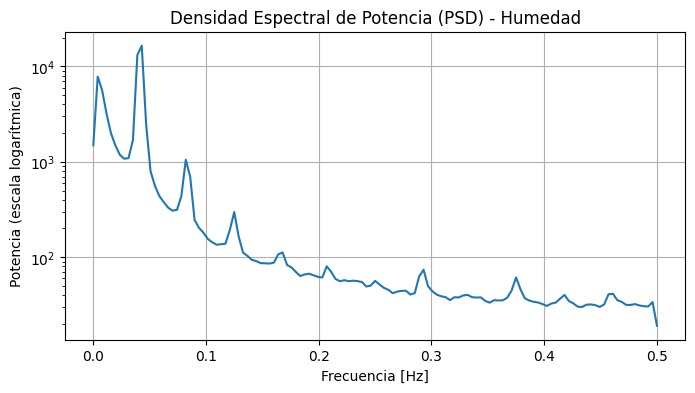

In [18]:
# ===== Celda 2: Calcular la PSD =====
import numpy as np
from scipy.signal import welch
import matplotlib.pyplot as plt

# 🔹 Limpieza: convertir strings a números y eliminar NaN
humidity_clean = pd.to_numeric(df['humidity'], errors='coerce')
humidity_clean = humidity_clean.dropna().values.astype(float)

print(f"✅ Total de datos válidos de humedad: {len(humidity_clean)}")

# 🔹 Calcular la PSD (Densidad Espectral de Potencia)
frequencies, psd = welch(humidity_clean, fs=1.0, nperseg=min(256, len(humidity_clean)))

# 🔹 Graficar PSD
plt.figure(figsize=(8,4))
plt.semilogy(frequencies, psd)
plt.title("Densidad Espectral de Potencia (PSD) - Humedad")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Potencia (escala logarítmica)")
plt.grid(True)
plt.show()


Escala los valores de humedad para que estén entre 0 y 1 esto con el fin de que Las redes neuronales suelen aprenden mejor cuando los datos están en un rango pequeño y uniforme.

In [19]:
# ===== Celda 3: Normalización =====
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(0, 1))
humidity_norm = scaler.fit_transform(humidity_clean.reshape(-1, 1))

print("Antes de normalizar:", humidity_clean[:5])
print("Después de normalizar:", humidity_norm[:5].flatten())


Antes de normalizar: [77. 77. 78. 78. 78.]
Después de normalizar: [0.77 0.77 0.78 0.78 0.78]


aqui se define la estructura de la red neuronal MLP
esta tiene una capa de entrada, una o más capas ocultas con ReLU, y una capa de salida.


esta red es la base que aprenderá la relación entre los datos de entrada y las salidas esperadas.

en este caso, queremos que la red aprenda los patrones de la humedad y pueda predecirlos.

In [20]:
# ===== Celda 4: Definición del modelo MLP =====
import torch
import torch.nn as nn

class MLPModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=32, output_size=1):
        super(MLPModel, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, output_size)
        )
    def forward(self, x):
        return self.net(x)

print("✅ Modelo MLP definido correctamente.")


✅ Modelo MLP definido correctamente.


optuna prubea muchas configuraciones y se queda con la mejor
lo que hace esta parte de codigo quiere entrenar esta red para que se parezca lo mas parecido a mis datos reales de la humedad , primero extrae los datos mas importantes de la humedad original y a partir de estos datos intenta reconstruir los datos originales

In [21]:
# ===== Celda 5: Optuna + PyTorch =====
!pip install optuna -q

import optuna
import torch
import torch.nn as nn
import numpy as np

# 🔹 Definición de modelo base
class MLP(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(MLP, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        return self.fc2(self.relu(self.fc1(x)))

# 🔹 Función objetivo para Optuna
def objective(trial):
    hidden_size = trial.suggest_int('hidden_size', 8, 64)
    lr = trial.suggest_float('lr', 1e-4, 1e-2, log=True)

    model = MLP(1, hidden_size, 1)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()

    # Datos simulados (seno) solo para la optimización
    X_train = torch.tensor(np.arange(0, 1, 0.01).reshape(-1, 1), dtype=torch.float32)
    y_train = torch.sin(2 * np.pi * X_train)

    for epoch in range(20):
        optimizer.zero_grad()
        y_pred = model(X_train)
        loss = loss_fn(y_pred, y_train)
        loss.backward()
        optimizer.step()

    return loss.item()

# 🔹 Ejecución del estudio
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=10)

print("✅ Mejor resultado encontrado por Optuna:")
print(study.best_params)


[I 2025-10-22 02:53:02,067] A new study created in memory with name: no-name-44538b43-6efa-49c0-9817-d6ad3473d4db
[I 2025-10-22 02:53:02,089] Trial 0 finished with value: 0.4943007528781891 and parameters: {'hidden_size': 50, 'lr': 0.0003022302185122446}. Best is trial 0 with value: 0.4943007528781891.
[I 2025-10-22 02:53:02,106] Trial 1 finished with value: 0.3879162669181824 and parameters: {'hidden_size': 37, 'lr': 0.00012577943218409257}. Best is trial 1 with value: 0.3879162669181824.
[I 2025-10-22 02:53:02,126] Trial 2 finished with value: 0.8882367014884949 and parameters: {'hidden_size': 51, 'lr': 0.00018216962719893427}. Best is trial 1 with value: 0.3879162669181824.
[I 2025-10-22 02:53:02,145] Trial 3 finished with value: 0.4364265501499176 and parameters: {'hidden_size': 32, 'lr': 0.002113703908027129}. Best is trial 1 with value: 0.3879162669181824.
[I 2025-10-22 02:53:02,163] Trial 4 finished with value: 0.3129439055919647 and parameters: {'hidden_size': 27, 'lr': 0.00543

✅ Mejor resultado encontrado por Optuna:
{'hidden_size': 19, 'lr': 0.0086132507393862}


lo que yo entendi es que si las dos graficas se parecen es que se hizo una buena MLP, que dice que va a predecir bien, en el caso de la humedad, podria predecir la humedad del dia siguiente osea si las curvas de validación son similares el modelo generaliza bien.

✅ Validación completada correctamente.


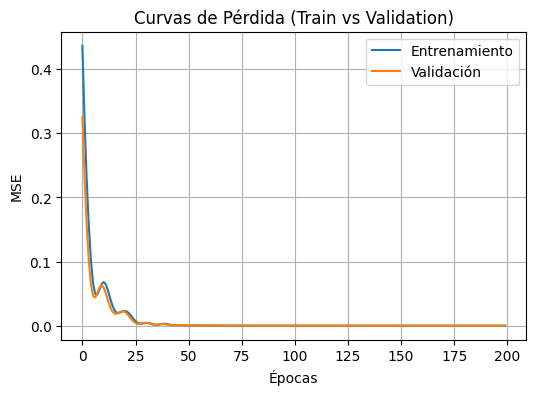

In [22]:
# ===== Celda 6: Validación del modelo =====
from sklearn.model_selection import train_test_split
import torch.optim as optim

# División del dataset (80% train, 20% validación)
X_train, X_val = train_test_split(humidity_norm, test_size=0.2, shuffle=False)

X_train_t = torch.tensor(X_train, dtype=torch.float32)
Y_train_t = X_train_t.clone()

X_val_t = torch.tensor(X_val, dtype=torch.float32)
Y_val_t = X_val_t.clone()

# Parámetros óptimos encontrados por Optuna
hidden_size = study.best_params['hidden_size']
lr = study.best_params['lr']

model = MLPModel(1, hidden_size, 1)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=lr)

train_loss_history = []
val_loss_history = []

for epoch in range(200):
    # Entrenamiento
    model.train()
    optimizer.zero_grad()
    y_pred = model(X_train_t)
    loss = criterion(y_pred, Y_train_t)
    loss.backward()
    optimizer.step()

    # Validación
    model.eval()
    with torch.no_grad():
        y_val_pred = model(X_val_t)
        val_loss = criterion(y_val_pred, Y_val_t)

    train_loss_history.append(loss.item())
    val_loss_history.append(val_loss.item())

print("✅ Validación completada correctamente.")

# Graficar pérdidas
plt.figure(figsize=(6,4))
plt.plot(train_loss_history, label="Entrenamiento")
plt.plot(val_loss_history, label="Validación")
plt.title("Curvas de Pérdida (Train vs Validation)")
plt.xlabel("Épocas")
plt.ylabel("MSE")
plt.legend()
plt.grid(True)
plt.show()


Prueba distintos tamaños de capa oculta (hidden_size) de forma manual.

Mide el error (MSE) de cada uno y lo grafica en una barra comparativa.

Te permite ver cómo afecta la arquitectura de la red al rendimiento.

También sirve para verificar si los resultados de Optuna son coherentes.

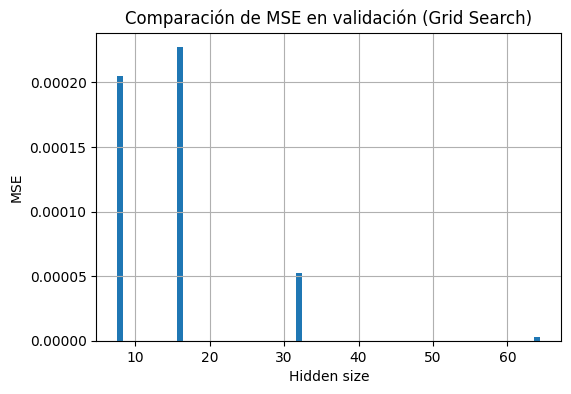

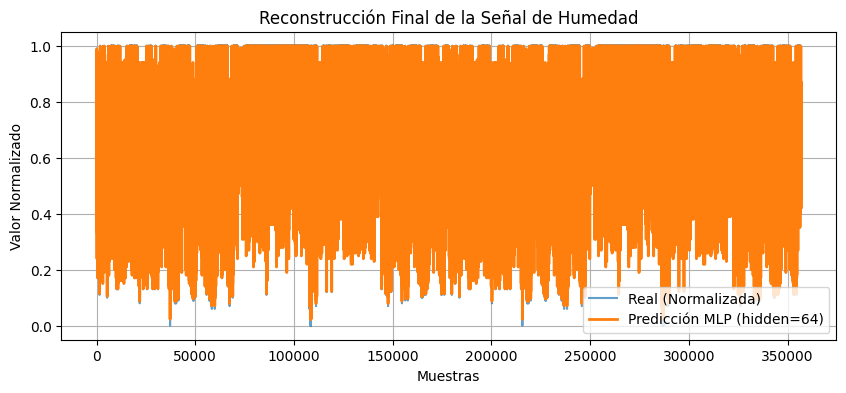

In [23]:
# ===== Celda 7: Comparación tipo Grid Search =====
hidden_sizes = [8, 16, 32, 64]
results = {}

for hs in hidden_sizes:
    model = MLPModel(1, hs, 1)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()

    for epoch in range(100):
        optimizer.zero_grad()
        y_pred = model(X_train_t)
        loss = criterion(y_pred, Y_train_t)
        loss.backward()
        optimizer.step()

    with torch.no_grad():
        y_val_pred = model(X_val_t)
        val_loss = criterion(y_val_pred, Y_val_t).item()
        results[hs] = val_loss

# Mostrar resultados comparativos
plt.figure(figsize=(6,4))
plt.bar(results.keys(), results.values())
plt.title("Comparación de MSE en validación (Grid Search)")
plt.xlabel("Hidden size")
plt.ylabel("MSE")
plt.grid(True)
plt.show()

# Graficar señal reconstruida con el mejor modelo
best_hs = min(results, key=results.get)
final_model = MLPModel(1, best_hs, 1)
optimizer = optim.Adam(final_model.parameters(), lr=lr)
for epoch in range(200):
    optimizer.zero_grad()
    y_pred = final_model(torch.tensor(humidity_norm, dtype=torch.float32))
    loss = criterion(y_pred, torch.tensor(humidity_norm, dtype=torch.float32))
    loss.backward()
    optimizer.step()

with torch.no_grad():
    final_output = final_model(torch.tensor(humidity_norm, dtype=torch.float32)).numpy()

plt.figure(figsize=(10,4))
plt.plot(humidity_norm, label="Real (Normalizada)", alpha=0.7)
plt.plot(final_output, label=f"Predicción MLP (hidden={best_hs})", linewidth=2)
plt.title("Reconstrucción Final de la Señal de Humedad")
plt.xlabel("Muestras")
plt.ylabel("Valor Normalizado")
plt.legend()
plt.grid(True)
plt.show()


esto me muestra la comparacion , osea la señal de entrada de humedad, cuanto se parece a la del modelo, y en este caso miramos que se asemeja mucho, por lo cual va a predecir casi igual

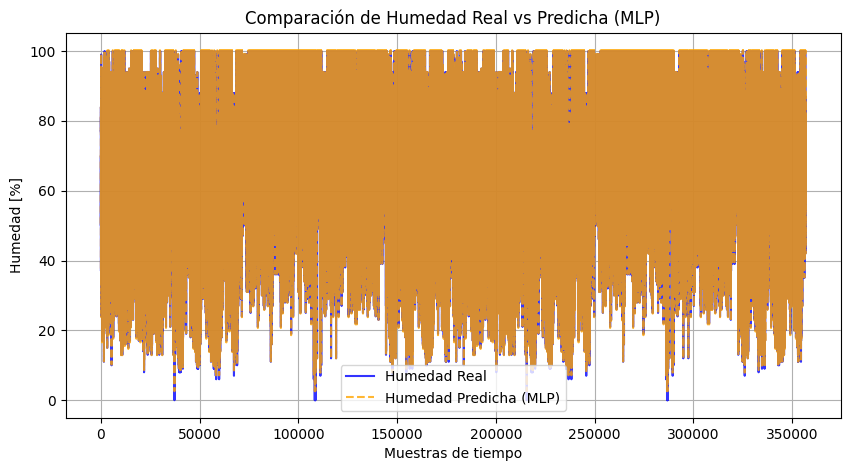

📉 Error cuadrático medio final (MSE): 0.025775


In [24]:
# ===== Celda 8: Comparación Real vs Predicho =====
import matplotlib.pyplot as plt
import torch

# 🔹 Pasar los datos normalizados a tensores
X_all = torch.tensor(humidity_norm, dtype=torch.float32)

# 🔹 Usar el modelo entrenado (de la celda 6)
model.eval()
with torch.no_grad():
    y_pred = model(X_all).numpy()

# 🔹 Invertir la normalización para volver a los valores reales de humedad (%)
humidity_real = scaler.inverse_transform(humidity_norm)
humidity_pred = scaler.inverse_transform(y_pred)

# 🔹 Graficar comparación
plt.figure(figsize=(10, 5))
plt.plot(humidity_real, label='Humedad Real', color='blue', alpha=0.8)
plt.plot(humidity_pred, label='Humedad Predicha (MLP)', color='orange', linestyle='--', alpha=0.8)
plt.title("Comparación de Humedad Real vs Predicha (MLP)")
plt.xlabel("Muestras de tiempo")
plt.ylabel("Humedad [%]")
plt.legend()
plt.grid(True)
plt.show()

# 🔹 Calcular error promedio
from sklearn.metrics import mean_squared_error
mse_final = mean_squared_error(humidity_real, humidity_pred)
print(f"📉 Error cuadrático medio final (MSE): {mse_final:.6f}")
